In [5]:
# Let's adjust params so that the new curve has a peak at exactly 1000 days and a less thick tail after 5000 days.
# Old curve is standard Gamma: p = 1, d = 2.43, a = 877.63.
# Let's verify peak location of old curve:
# Mode = (d - 1) * a = (2.43 - 1) * 877.63 = 1255.01 dias.
#
# To achieve a peak at 1000 days (pico mais próximo da origem) AND a less thick tail (queda mais rápida após 5000),
# we increase the power parameter 'p' from 1.0 to, say, 1.5 ou 2.0.
# Let's test p = 1.5, d = 3.0:
p_new = 1.5
d_new = 3.0
# x_peak = a * ((d - 1) / p) ** (1 / p) = 1000
a_new = 1000 / ((d_new - 1) / p_new) ** (1 / p_new)

print(f"Nova curva sugerida:\nEscala (a) = {a_new:.2f}\nForma (d) = {d_new:.2f}\nPotência (p) = {p_new:.2f}")


Nova curva sugerida:
Escala (a) = 825.48
Forma (d) = 3.00
Potência (p) = 1.50


1/escala = 0.0011394 | taxa informada = 0.0011394


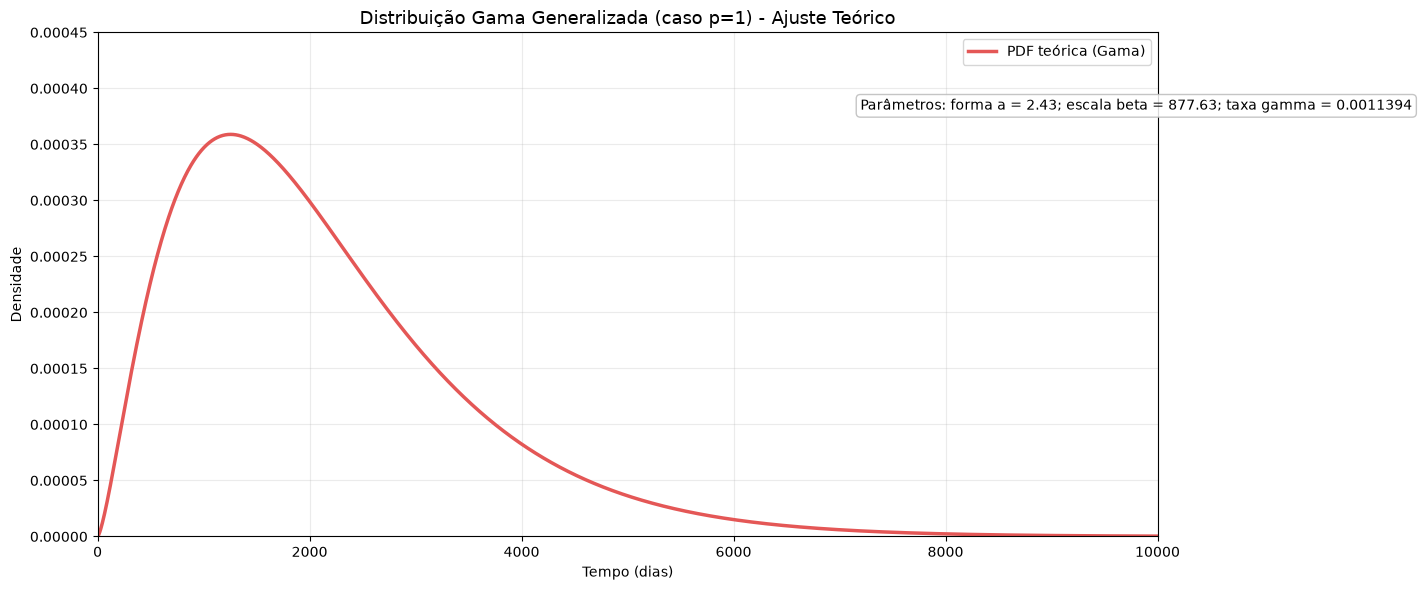

Figura reproduzida salva em: e:\DADOS\Documents\AmbienteDeTrabalho\Projetos\notebook\fig\Rafael_tempo_tramitacao_1grau_teste_adequacao_modelo_epdf-x-pdf_GamaGeneralizada_reproducao_parametros_fixos.jpeg


In [11]:
# Passo a passo da célula:
# 1) Definir os parâmetros informados da distribuição Gama (caso p=1 da Gama Generalizada).
# 2) Construir a grade do eixo x no intervalo fechado [0, 10000] dias.
# 3) Calcular a densidade teórica usando shape (forma) e scale (escala).
# 4) Plotar a curva com os limites de eixos iguais aos da figura de referência.
# 5) Incluir os parâmetros abaixo da legenda e salvar a figura final.

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Parâmetros fornecidos na descrição da figura original.
forma_a = 2.43
escala_beta = 877.63
taxa_gama = 0.0011394  # taxa = 1 / escala

# Consistência entre taxa e escala (diferença apenas por arredondamento).
print(f"1/escala = {1/escala_beta:.7f} | taxa informada = {taxa_gama:.7f}")

# Grade no eixo x exatamente no intervalo solicitado.
x = np.linspace(0, 10000, 2001)

# PDF da Gama (equivalente à Gama Generalizada quando p=1).
# scipy.stats.gamma usa: a=shape, scale=escala.
pdf = gamma.pdf(x, a=forma_a, scale=escala_beta)

# Gera a figura no mesmo enquadramento da referência.
plt.figure(figsize=(12, 6))
plt.plot(x, pdf, color="#E45756", linewidth=2.5, label="PDF teórica (Gama)")

plt.title("Distribuição Gama Generalizada (caso p=1) - Ajuste Teórico", fontsize=13)
plt.xlabel("Tempo (dias)")
plt.ylabel("Densidade")
plt.xlim(0, 10000)
plt.ylim(0, 0.00045)
plt.grid(alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()

# Inclui, abaixo da legenda, um quadro com os parâmetros usados.
texto_parametros = (
    f"Parâmetros: forma a = {forma_a:.2f}; escala beta = {escala_beta:.2f}; taxa gamma = {taxa_gama:.7f}"
)
ax = plt.gca()
ax.text(
    0.98, 0.84, texto_parametros,
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="#BBBBBB")
)

# Salva sem sobrescrever a imagem original.
BASE = Path.cwd()
arq_saida = BASE / "fig" / "Rafael_tempo_tramitacao_1grau_teste_adequacao_modelo_epdf-x-pdf_GamaGeneralizada_reproducao_parametros_fixos.jpeg"
arq_saida.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(arq_saida, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura reproduzida salva em: {arq_saida}")


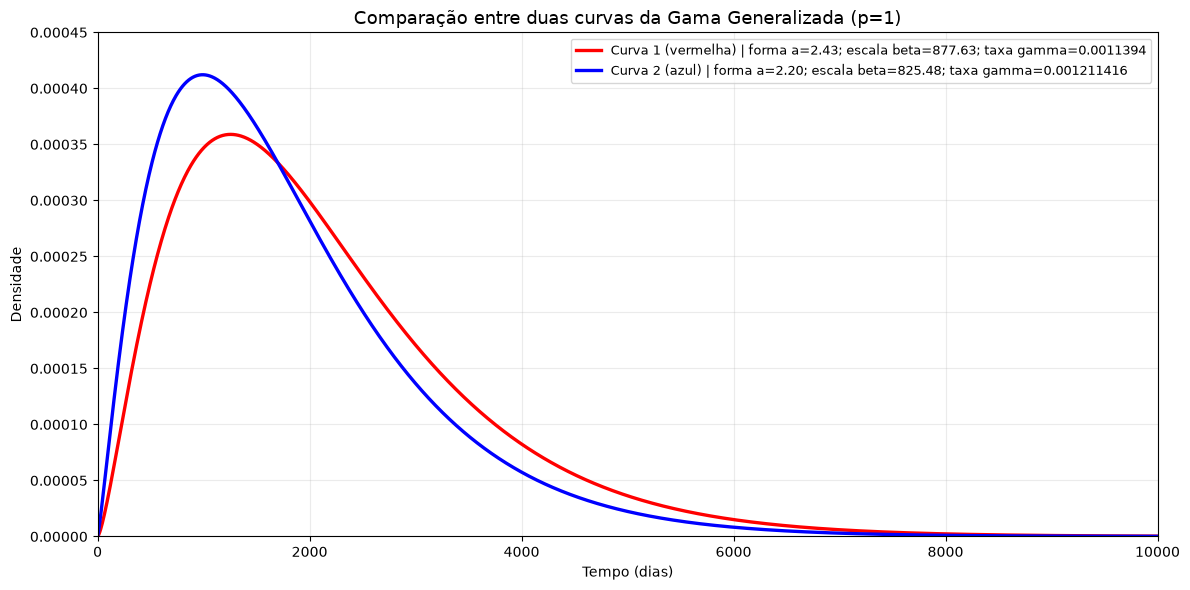

Comparação concluída: curva vermelha (anterior) x curva azul (nova).

Tabela 1. Medidas de posição e dispersão das curvas gama (dias)
                      Curva Média (dias) Desvio-padrão (dias) Mediana (dias) Amplitude interquartil (dias)
                   Vermelha     2,132.64             1,368.09       1,848.31                      1,705.38
                       Azul     1,816.06             1,224.38       1,549.54                      1,512.98
Diferença (Vermelha - Azul)       316.58               143.71         298.77                        192.40


In [20]:
# Passo a passo da célula:
# 1) Definir os parâmetros das duas curvas de referência
#   (modelo anterior e modelo novo).
# 2) Criar uma grade de valores de x no intervalo de 0 a 10000 dias.
# 3) Calcular as densidades teóricas para as duas distribuições.
# 4) Plotar as duas curvas no mesmo gráfico (vermelha e azul).
# 5) Exibir legenda com identificação de cada curva e 
#    seus respectivos parâmetros.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gamma

# Parametros da curva 1 (anterior).
a1 = 2.43
beta1 = 877.63
gama1 = 0.0011394

# Parametros da curva 2 (nova).
a2 = 2.20
beta2 = 825.48
gama2 = 0.001211416

# Grade no eixo x para comparação direta entre as curvas.
x = np.linspace(0, 10000, 2001)

# Cálculo das PDFs (caso p=1 da Gama Generalizada).
pdf1 = gamma.pdf(x, a=a1, scale=beta1)
pdf2 = gamma.pdf(x, a=a2, scale=beta2)

media1 = gamma.mean(a=a1, scale=beta1)
mediana1 = gamma.median(a=a1, scale=beta1)
media2 = gamma.mean(a=a2, scale=beta2)
mediana2 = gamma.median(a=a2, scale=beta2)

desvio1 = gamma.std(a=a1, scale=beta1)
desvio2 = gamma.std(a=a2, scale=beta2)

q1_1 = gamma.ppf(0.25, a=a1, scale=beta1)
q3_1 = gamma.ppf(0.75, a=a1, scale=beta1)
aiq1 = q3_1 - q1_1

q1_2 = gamma.ppf(0.25, a=a2, scale=beta2)
q3_2 = gamma.ppf(0.75, a=a2, scale=beta2)
aiq2 = q3_2 - q1_2

# Monta o gráfico comparativo das duas distribuições.
plt.figure(figsize=(12, 6))
plt.plot(
    x, pdf1, color="red", linewidth=2.4,
    label=(
        f"Curva 1 (vermelha) | forma a={a1:.2f}; escala beta={beta1:.2f}; "
        f"taxa gamma={gama1:.7f}"
    )
)
plt.plot(
    x, pdf2, color="blue", linewidth=2.4,
    label=(
        f"Curva 2 (azul) | forma a={a2:.2f}; escala beta={beta2:.2f}; "
        f"taxa gamma={gama2:.9f}"
    )
)

# Configurações visuais para manter o 
# mesmo enquadramento da figura-base.
plt.title("Comparação entre duas curvas da Gama Generalizada (p=1)", fontsize=13)
plt.xlabel("Tempo (dias)")
plt.ylabel("Densidade")
plt.xlim(0, 10000)
plt.ylim(0, 0.00045)
plt.grid(alpha=0.25)
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("Comparação concluída: curva vermelha (anterior) x curva azul (nova).")

# Tabela sintética com média, desvio-padrão, mediana e amplitude interquartil.
tabela_sintetica = pd.DataFrame([
    {
        "Curva": "Vermelha",
        "Média (dias)": media1,
        "Desvio-padrão (dias)": desvio1,
        "Mediana (dias)": mediana1,
        "Amplitude interquartil (dias)": aiq1,
    },
    {
        "Curva": "Azul",
        "Média (dias)": media2,
        "Desvio-padrão (dias)": desvio2,
        "Mediana (dias)": mediana2,
        "Amplitude interquartil (dias)": aiq2,
    },
    {
        "Curva": "Diferença (Vermelha - Azul)",
        "Média (dias)": media1 - media2,
        "Desvio-padrão (dias)": desvio1 - desvio2,
        "Mediana (dias)": mediana1 - mediana2,
        "Amplitude interquartil (dias)": aiq1 - aiq2,
    },
])

# Formato típico de artigo: valores com duas casas, colunas alinhadas e rótulo da tabela.
tabela_artigo = tabela_sintetica.copy()
for col in ["Média (dias)", "Desvio-padrão (dias)", "Mediana (dias)", "Amplitude interquartil (dias)"]:
    tabela_artigo[col] = tabela_artigo[col].map(lambda v: f"{v:,.2f}")

print("\nTabela 1. Medidas de posição e dispersão das curvas gama (dias)")
print(tabela_artigo.to_string(index=False))
